[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter5_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 5: Heavy tails and extreme value theory

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Crash days and the Normal distribution; light and heavy tails; regular variation and the tail index.
- The Hill estimator, the Hill plot, standard errors and the Hill quantile; the mean excess function.
- Block maxima and the GEV distribution (Fisher–Tippett–Gnedenko); peaks over threshold and the GPD (Pickands–Balkema–de Haan); return levels.
- VaR 1%, ES 2.5% and VaR 0.1% by EVT, historical simulation and the Normal distribution; an out-of-sample check.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 18; McNeil, Frey and Embrechts (2015), *Quantitative Risk Management*, Ch. 5; McNeil and Frey (2000).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_5'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily losses $L_t = -r_t$ in %, with $r_t = 100(\ln P_t - \ln P_{t-1})$; S&P 500 and DAX since 1990, BET since 1997, Bitcoin since 2014, BVB stocks since 2010 (Banca Transilvania without 30–31 May 2016, a data error).
- Hill estimator: $\hat\alpha_k = [\frac1k\sum_{i=1}^k \ln(L_{(i)}/L_{(k+1)})]^{-1}$, here $k = 2.5\%$ of $n$.
- POT: threshold $u$ = the 90% quantile of the losses; GPD for the excesses; $\mathrm{VaR}_p = u + \frac{\beta}{\xi}[(np/N_u)^{-\xi} - 1]$, $\mathrm{ES}_p = (\mathrm{VaR}_p + \beta - \xi u)/(1 - \xi)$.
- scipy: `genextreme` uses the shape $c = -\xi$; `genpareto` uses $c = \xi$.

In [5]:
from scipy import optimize
START = {'sp500': '1990-01-01', 'dax': '1990-01-01', 'bet': '1997-01-01', 'btc': None, 'snp': '2010-01-01', 'brd': '2010-01-01', 'tlv': '2010-01-01', 'tgn': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc']
STOCKS = ['snp', 'brd', 'tlv', 'tgn']
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'snp': '#2E7D32', 'brd': '#8E44AD', 'tlv': '#E67E22', 'tgn': '#DC3545'}
MODEL_COL = {'Data': '#B5853F', 'Normal': '#CD0000', 'EVT': '#1A3A6E', 'Historical': '#2E7D32', 'Hill': '#8E44AD'}
SEED = 2026
HILL_FRAC = 0.025
POT_Q = 0.9
SPLIT = '2019-12-31'
BLOCK = 20


def returns(k):
    """Daily log returns in % on the series' own calendar (S&P 500 and DAX since 1990, BET since its launch in
    1997, Bitcoin since 2014, BVB stocks since 2010); known data errors removed."""
    r = log_returns(k, START.get(k))
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def losses(k):
    """Daily losses L_t = -r_t in % (a positive number is a loss)."""
    return -returns(k)


def hill(x, k):
    """Hill (1975): alpha_hat(k) = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^(-1), X_(1) >= X_(2) >= ..."""
    x = np.sort(np.asarray(x, float))[::-1]
    return 1.0 / np.mean(np.log(x[:k] / x[k]))


def hill_quantile(x, k, p):
    """Hill (Weissman, 1978) quantile: x_p = X_(k+1) (k / (n p))^(1/alpha_hat), the loss exceeded with probability p."""
    x = np.sort(np.asarray(x, float))[::-1]
    return x[k] * (k / (len(x) * p)) ** (1 / hill(x, k))


def ls_tail_index(x, k):
    """Least-squares tail index (as in SFElshill): slope of ln(i/n) on ln X_(i), i = 1..k, is -alpha."""
    n = len(x)
    x = np.sort(np.asarray(x, float))[::-1][:k]
    return -np.polyfit(np.log(x), np.log(np.arange(1, k + 1) / n), 1)[0]


def block_indices(n, block, rng):
    """Indices of one moving-block bootstrap sample (blocks of `block` consecutive days)."""
    nb = int(np.ceil(n / block))
    s = rng.integers(0, n - block + 1, nb)
    return (s[:, None] + np.arange(block)[None, :]).ravel()[:n]


def hill_inference(x, frac=HILL_FRAC, B=500, block=BLOCK, seed=SEED):
    """Hill alpha_hat at k = frac n with the i.i.d. standard error alpha/sqrt(k), the 95% interval
    alpha (1 +/- 1.96/sqrt(k)) and the moving-block bootstrap standard error (blocks of 20 days)."""
    x = np.asarray(x, float)
    n = len(x)
    k = int(frac * n)
    a = hill(x, k)
    rng = np.random.default_rng(seed)
    bs = np.array([hill(x[block_indices(n, block, rng)], k) for _ in range(B)])
    return {'n': n, 'k': k, 'u': float(np.sort(x)[::-1][k]), 'alpha': a, 'se_iid': a / np.sqrt(k),
            'lo': a * (1 - 1.96 / np.sqrt(k)), 'hi': a * (1 + 1.96 / np.sqrt(k)), 'se_block': float(np.std(bs, ddof=1)),
            'alpha_1': hill(x, int(0.01 * n)), 'alpha_5': hill(x, int(0.05 * n)), 'ls': ls_tail_index(x, k)}


def gev_cdf(x, xi, mu, sigma):
    """GEV distribution function H(x) = exp{-[1 + xi (x - mu)/sigma]^(-1/xi)} (xi = 0: Gumbel)."""
    return stats.genextreme.cdf(x, -xi, mu, sigma)          # scipy's shape c = -xi


def gev_ppf(p, xi, mu, sigma):
    return stats.genextreme.ppf(p, -xi, mu, sigma)


def gev_pdf(x, xi, mu, sigma):
    return stats.genextreme.pdf(x, -xi, mu, sigma)


def gpd_sf(y, xi, beta):
    """GPD survival function P(Y > y) = (1 + xi y / beta)^(-1/xi) for the excess Y = X - u (xi = 0: exponential)."""
    return stats.genpareto.sf(y, xi, 0, beta)


def num_hessian(f, p, h=1e-4):
    """Numerical Hessian of f at p (central differences)."""
    p = np.asarray(p, float)
    k = len(p)
    H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            e_i, e_j = np.eye(k)[i] * h, np.eye(k)[j] * h
            H[i, j] = (f(p + e_i + e_j) - f(p + e_i - e_j) - f(p - e_i + e_j) + f(p - e_i - e_j)) / (4 * h * h)
    return H


def fit_gev(m):
    """Maximum likelihood GEV fit (xi, mu, sigma) of block maxima m, standard errors from the numerical Hessian."""
    m = np.asarray(m, float)
    c, mu, sig = stats.genextreme.fit(m, -0.1, loc=np.mean(m), scale=np.std(m))
    nll = lambda p: -np.sum(stats.genextreme.logpdf(m, -p[0], p[1], p[2])) if p[2] > 0 else np.inf
    res = optimize.minimize(nll, [-c, mu, sig], method='Nelder-Mead', options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 5000})
    xi, mu, sig = res.x
    cov = np.linalg.inv(num_hessian(nll, res.x))
    se = np.sqrt(np.diag(cov))
    return {'xi': xi, 'mu': mu, 'sigma': sig, 'se_xi': se[0], 'se_mu': se[1], 'se_sigma': se[2], 'nll': res.fun, 'n': len(m)}


def fit_gpd(y):
    """Maximum likelihood GPD fit (xi, beta) of excesses y > 0, standard errors from the numerical Hessian."""
    y = np.asarray(y, float)
    c, _, b = stats.genpareto.fit(y, floc=0)
    nll = lambda p: -np.sum(stats.genpareto.logpdf(y, p[0], 0, p[1])) if p[1] > 0 else np.inf
    res = optimize.minimize(nll, [c, b], method='Nelder-Mead', options={'xatol': 1e-9, 'fatol': 1e-9, 'maxiter': 5000})
    xi, beta = res.x
    se = np.sqrt(np.diag(np.linalg.inv(num_hessian(nll, res.x))))
    return {'xi': xi, 'beta': beta, 'se_xi': se[0], 'se_beta': se[1], 'nll': res.fun, 'n_u': len(y)}


def return_level(g, months):
    """Level exceeded by the monthly maximum on average once every `months` months: z = H^(-1)(1 - 1/months)."""
    return float(gev_ppf(1 - 1 / months, g['xi'], g['mu'], g['sigma']))


def pot(x, q=POT_Q):
    """GPD fit to the losses above the threshold u = q-quantile of the losses x."""
    x = np.asarray(x, float)
    u = float(np.quantile(x, q))
    f = fit_gpd(x[x > u] - u)
    f.update({'u': u, 'n': len(x), 'q': q})
    return f


def pot_var(f, p):
    """VaR_p = u + (beta/xi) [ (n p / N_u)^(-xi) - 1 ], the loss exceeded with probability p."""
    return f['u'] + f['beta'] / f['xi'] * ((f['n'] * p / f['n_u']) ** (-f['xi']) - 1)


def pot_es(f, p):
    """ES_p = VaR_p / (1 - xi) + (beta - xi u) / (1 - xi), the mean loss beyond VaR_p (xi < 1)."""
    return pot_var(f, p) / (1 - f['xi']) + (f['beta'] - f['xi'] * f['u']) / (1 - f['xi'])


def pot_tail_prob(f, x):
    """P(L > x) = (N_u / n) (1 + xi (x - u) / beta)^(-1/xi) for x > u."""
    return f['n_u'] / f['n'] * (1 + f['xi'] * (np.asarray(x, float) - f['u']) / f['beta']) ** (-1 / f['xi'])


def normal_var(x, p):
    """Normal VaR_p of losses x: mu_L + sigma_L z_(1-p)."""
    return float(np.mean(x) + np.std(x, ddof=1) * stats.norm.isf(p))


def normal_es(x, p):
    """Normal ES_p of losses x: mu_L + sigma_L phi(z_p) / p."""
    return float(np.mean(x) + np.std(x, ddof=1) * stats.norm.pdf(stats.norm.isf(p)) / p)


def hist_var(x, p):
    """Historical VaR_p: the empirical (1 - p) quantile of the losses."""
    return float(np.quantile(x, 1 - p))


def hist_es(x, p):
    """Historical ES_p: the mean of the losses at or above the historical VaR_p."""
    x = np.asarray(x, float)
    return float(x[x >= hist_var(x, p)].mean())


def mean_excess(x, us):
    """Empirical mean excess e(u) = mean of (X - u) over the observations X > u."""
    x = np.asarray(x, float)
    return np.array([np.mean(x[x > u] - u) if np.sum(x > u) >= 5 else np.nan for u in us])

## 1. Why tails matter: crash days

- The largest daily loss of each series, its z-score and its waiting time under the Normal distribution.
- 19 October 1987: the S&P 500 fell about 20% (Carlson, 2007).

In [6]:
def crash_table(names=ASSETS):
    """The largest daily loss of each series, its z-score under the Normal distribution fitted to the whole sample,
    the Normal probability of such a loss and the implied waiting time in years (252 trading days, 365 for Bitcoin)."""
    out = {}
    for k in names:
        r = returns(k)
        mu, sd = r.mean(), r.std()
        d = r.idxmin()
        z = (r.min() - mu) / sd
        p = stats.norm.cdf(z)
        days = 365 if k == 'btc' else 252
        out[k] = {'date': d.date().isoformat(), 'ret': float(r.min()), 'mu': float(mu), 'sd': float(sd), 'z': float(z),
                  'logp': float(stats.norm.logcdf(z) / np.log(10)), 'n': len(r), 'first': r.index[0].date().isoformat(),
                  'years': float(1 / (p * days)) if p > 0 else float('inf'),
                  'log_years': float(-stats.norm.logcdf(z) / np.log(10) - np.log10(days)),
                  'n_below_4sd': int((r < mu - 4 * sd).sum()), 'exp_below_4sd': float(len(r) * stats.norm.cdf(-4))}
    return out


def worst_days(names=ASSETS, m=3):
    """The m largest daily losses of each series (at most one per calendar month), with their dates."""
    out = {}
    for k in names:
        r = returns(k).nsmallest(40)
        r = r[~pd.Series(r.index.to_period('M'), index=r.index).duplicated()].iloc[:m]
        out[k] = [{'date': d.date().isoformat(), 'ret': float(v)} for d, v in r.items()]
    return out


def crash_1987(k='sp500', drop=0.20):
    """19 October 1987: the S&P 500 fell about 20% (Carlson, 2007). Its log return and Normal z-score with the
    mean and standard deviation of the S&P 500 daily log returns since 1990."""
    r = returns(k)
    x = 100 * np.log(1 - drop)
    z = (x - r.mean()) / r.std()
    return {'logret': float(x), 'z': float(z), 'log10p': float(stats.norm.logcdf(z) / np.log(10))}


def fig_crash_days(save=True):
    """Daily log returns of the S&P 500 and the BET with the level of a 1-in-100-years loss under the Normal law."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), sharex=False)
    out = {}
    for ax, k in zip(axes, ['sp500', 'bet']):
        r = returns(k)
        mu, sd = r.mean(), r.std()
        lvl = mu + sd * stats.norm.ppf(1 / (100 * 252))
        ax.plot(r.index, r.values, color=COLORS[k], lw=0.5, label=f'{LABELS[k]} daily log return (%)')
        ax.axhline(lvl, color='black', lw=0.9, ls='--', label='Normal model: loss seen once in 100 years')
        worst = r.nsmallest(20)
        worst = worst[~pd.Series(worst.index.to_period('M'), index=worst.index).duplicated()].iloc[:3]   # one per month
        for d, v in worst.items():
            ax.annotate(d.strftime('%d %b %Y'), (d, v), xytext=(8, -2), textcoords='offset points', fontsize=9.5, color='black')
        ax.set_ylabel('%')
        ax.set_title(LABELS[k], loc='left', fontsize=12)
        out[k] = {'level100': float(lvl), 'n_below': int((r < lvl).sum())}
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_crash_days')
    return out

In [7]:
pd.DataFrame(crash_table()).T[['date', 'ret', 'z', 'log_years', 'n_below_4sd', 'exp_below_4sd']]

,date,ret,z,log_years,n_below_4sd,exp_below_4sd
sp500,2020-03-16,-12.765218,-11.289252,26.728508,35,0.292642
dax,2020-03-12,-13.05486,-9.540694,18.747708,27,0.294162
bet,2009-01-07,-13.116763,-8.901938,16.160215,33,0.229395
btc,2020-03-12,-46.473021,-13.368295,37.771937,18,0.138847


{'logret': -22.31435513142097, 'z': -19.712445938121768, 'log10p': -86.0741298536244}


{'sp500': {'level100': -4.440731785870551, 'n_below': 35},
 'bet': {'level100': -5.787962291446114, 'n_below': 34}}

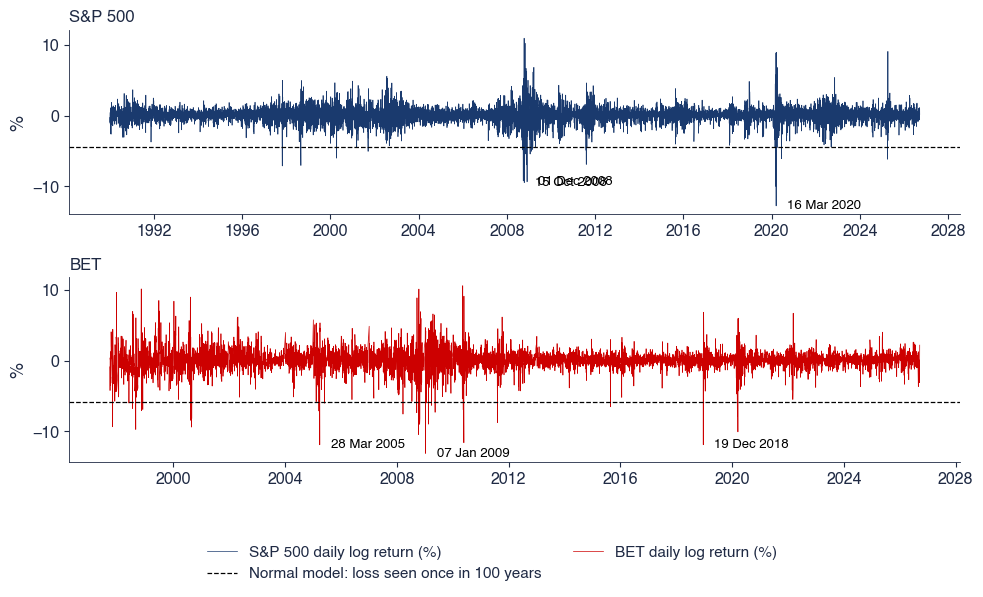

In [8]:
print(crash_1987())
fig_crash_days(save=False)

## 2. Light and heavy tails; regular variation

- On log-log axes a power law $P(L > x) \approx Cx^{-\alpha}$ is a straight line with slope $-\alpha$.
- The least-squares slope through the 2.5% largest losses (as in the SFE Quantlet SFElshill).

In [9]:
def fig_light_heavy(save=True):
    """P(X > x) on log-log axes: Normal and Exponential (light tails) against Student-t(3) and Pareto(3) (heavy)."""
    x = np.logspace(0, 2, 300)
    fig, ax = plt.subplots(figsize=(10, 4.2))
    sd_t = np.sqrt(3)                                     # standard deviation of the Student-t with 3 d.f.
    ax.loglog(x, stats.norm.sf(x), color=MODEL_COL['Normal'], label='Normal N(0, 1)')
    ax.loglog(x, stats.expon.sf(x), color='#2E7D32', label='Exponential (1)')
    ax.loglog(x, stats.t.sf(x, 3), color='#1A3A6E', label='Student-t, 3 degrees of freedom')
    ax.loglog(x, x ** -3.0, color='#8E44AD', ls='--', label='Pareto: P(X > x) = x^(-3)')
    ax.set_ylim(1e-12, 1.2)
    ax.set_xlabel('x (log scale)')
    ax.set_ylabel('P(X > x) (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_light_heavy')
    return {'t10': float(stats.t.sf(10, 3)), 'n10': float(stats.norm.sf(10)), 'e10': float(stats.expon.sf(10)),
            'p10': 10 ** -3.0, 't_ratio': float(stats.t.sf(20, 3) / stats.t.sf(10, 3)), 'sd_t': sd_t}


def fig_loglog_real(save=True):
    """Empirical P(L > x) of daily losses on log-log axes with the least-squares line through the 2.5% largest losses
    (slope = -alpha, as in SFElshill) and the Normal tail."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.4))
    out = {}
    for ax, k in zip(axes.flat, ASSETS):
        x = losses(k).values
        n = len(x)
        s = np.sort(x[x > 0])[::-1]
        emp = np.arange(1, len(s) + 1) / n
        ax.loglog(s, emp, '.', ms=2.5, color=COLORS[k], label='Data: share of days with a loss above x')
        kk = int(HILL_FRAC * n)
        a_ls = ls_tail_index(x, kk)
        c = np.exp(np.mean(np.log(emp[:kk]) + a_ls * np.log(s[:kk])))
        xx = np.logspace(np.log10(s[kk]), np.log10(1.5 * s[0]), 50)
        ax.loglog(xx, c * xx ** -a_ls, color='black', lw=1.2, label='Least-squares line, 2.5% largest losses')
        xs = np.logspace(np.log10(0.3), np.log10(1.5 * s[0]), 200)
        pn = stats.norm.sf(xs, np.mean(x), np.std(x, ddof=1))
        ax.loglog(xs[pn > 1e-7], pn[pn > 1e-7], color=MODEL_COL['Normal'], ls='--', label='Normal distribution')
        ax.set_ylim(1e-5, 1)
        ax.set_xlim(0.3, 1.5 * s[0])
        ax.set_title(f'{LABELS[k]}: slope -{a_ls:.2f}', loc='left', fontsize=12)
        ax.set_xlabel('Loss x (%, log scale)')
        ax.set_ylabel('P(L > x)')
        out[k] = a_ls
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_loglog_real')
    return out

{'t10': 0.0010641995292070756,
 'n10': 7.619853024160474e-24,
 'e10': 4.5399929762484854e-05,
 'p10': 0.001,
 't_ratio': 0.12836091482340378,
 'sd_t': np.float64(1.7320508075688772)}

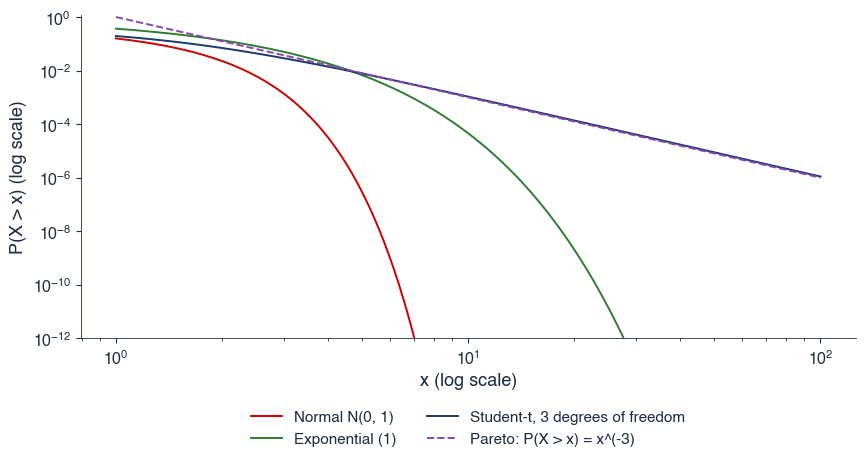

In [10]:
fig_light_heavy(save=False)

{'sp500': np.float64(3.0004228335755045),
 'dax': np.float64(3.5681849836820856),
 'bet': np.float64(2.7946842444806945),
 'btc': np.float64(3.000239974337903)}

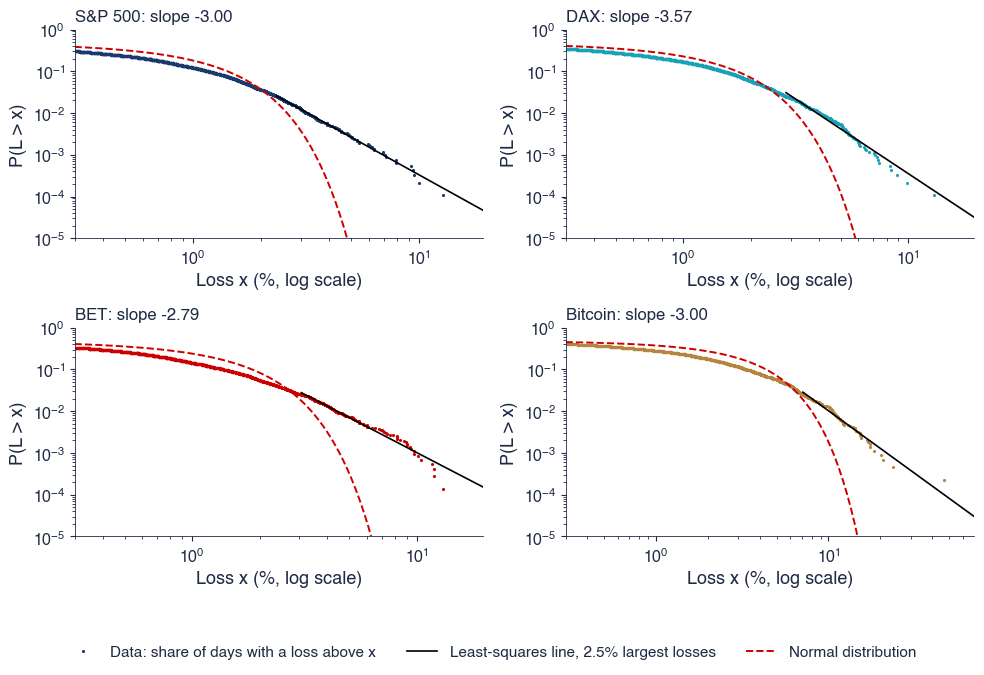

In [11]:
fig_loglog_real(save=False)

## 3. The Hill estimator

- Hill plot: $\hat\alpha_k$ against $k/n$; inference at $k = 2.5\%$ of $n$: i.i.d. SE $\hat\alpha/\sqrt{k}$ and moving-block bootstrap SE (blocks of 20 days).
- Hill (Weissman) quantile $\hat x_p = L_{(k+1)}(k/(np))^{1/\hat\alpha}$.

In [12]:
def fig_hill_plot(names=ASSETS, fname='sfm_ch5_hill_plot', band='sp500', save=True):
    """Hill plot: alpha_hat(k) of daily losses against k/n (0.5% to 10%), with the i.i.d. 95% band for one series."""
    fig, ax = plt.subplots(figsize=(10, 4.2))
    fr = np.round(np.arange(0.005, 0.1001, 0.0025), 4)
    out = {}
    for k in names:
        x = losses(k).values
        n = len(x)
        a = np.array([hill(x, max(int(f * n), 5)) for f in fr])
        ax.plot(100 * fr, a, color=COLORS[k], lw=1.5, label=LABELS[k])
        if k == band:
            kk = np.maximum((fr * n).astype(int), 5)
            ax.fill_between(100 * fr, a * (1 - 1.96 / np.sqrt(kk)), a * (1 + 1.96 / np.sqrt(kk)), color=COLORS[k], alpha=0.15,
                            lw=0, label=f'{LABELS[k]}: 95% interval')
        out[k] = {f'{f:.4f}': float(v) for f, v in zip(fr, a)}
    ax.axvline(100 * HILL_FRAC, color='black', lw=0.8, ls=':', label='k = 2.5% of n')
    ax.axhline(2, color='black', lw=0.8, ls='--', label='alpha = 2: variance finite above')
    ax.axhline(4, color='black', lw=0.8, ls='-.', label='alpha = 4: kurtosis finite above')
    ax.set_xlabel('Share of the largest losses used, k/n (%)')
    ax.set_ylabel('Hill estimate of alpha')
    ax.set_ylim(1, 6)
    st.legend_outside_bottom(ax, ncol=4, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig(fname)
    return out


def hill_table(names=ASSETS + STOCKS):
    """Hill inference for losses and gains of each series; least-squares index; Hill quantiles."""
    out = {}
    for k in names:
        r = returns(k)
        L = -r.values
        h = hill_inference(L)
        g = hill(r.values, h['k'])
        out[k] = dict(h, alpha_gain=g, first=r.index[0].date().isoformat(), last=r.index[-1].date().isoformat())
    return out

{'sp500': {'0.0050': 2.9662136501985166,
  '0.0075': 3.0400274359782706,
  '0.0100': 2.953957841465062,
  '0.0125': 3.1512352426675543,
  '0.0150': 3.1870915448208255,
  '0.0175': 2.9176931890012825,
  '0.0200': 2.965827029738549,
  '0.0225': 3.001833337064646,
  '0.0250': 2.9716716075103298,
  '0.0275': 2.9114974662074444,
  '0.0300': 2.844611745549883,
  '0.0325': 2.8278495529861862,
  '0.0350': 2.743401348086746,
  '0.0375': 2.6577539625453817,
  '0.0400': 2.6075941115587113,
  '0.0425': 2.6112033281708427,
  '0.0450': 2.630616888510923,
  '0.0475': 2.609206733322944,
  '0.0500': 2.5556725422819246,
  '0.0525': 2.5350946624266704,
  '0.0550': 2.512475705610104,
  '0.0575': 2.4848694777572344,
  '0.0600': 2.487525065572336,
  '0.0625': 2.481521599746725,
  '0.0650': 2.468471316713261,
  '0.0675': 2.4212432377153386,
  '0.0700': 2.390553864422506,
  '0.0725': 2.378789460165677,
  '0.0750': 2.3414301914222566,
  '0.0775': 2.3348015432709355,
  '0.0800': 2.303592310278012,
  '0.0825': 2

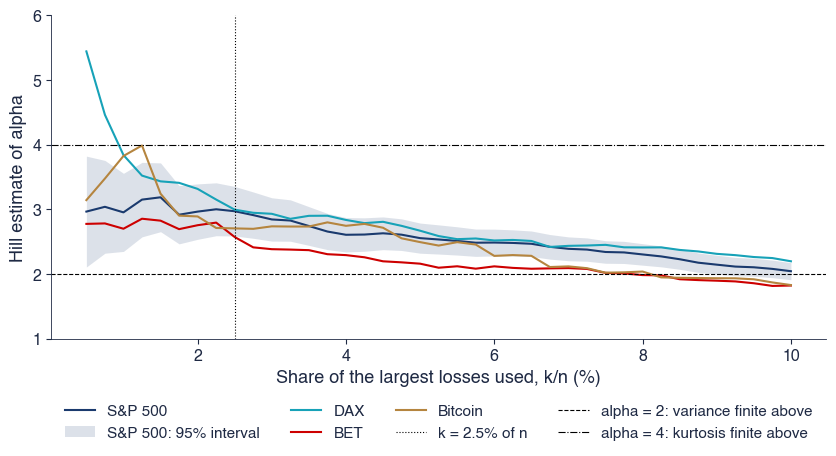

In [13]:
fig_hill_plot(save=False)

In [14]:
ht = hill_table()
pd.DataFrame(ht).T[['n', 'k', 'alpha', 'lo', 'hi', 'se_iid', 'se_block', 'alpha_1', 'alpha_5', 'alpha_gain']].round(2)

,n,k,alpha,lo,hi,se_iid,se_block,alpha_1,alpha_5,alpha_gain
sp500,9240,231,2.971672,2.588449,3.354894,0.195522,0.301945,2.953958,2.555673,2.957316
dax,9288,232,2.995846,2.61034,3.381353,0.196687,0.200443,3.840167,2.670319,3.221708
bet,7243,181,2.572659,2.19786,2.947459,0.191224,0.226206,2.701038,2.160841,2.816362
btc,4384,109,2.706288,2.198226,3.21435,0.259215,0.227263,3.825692,2.494082,3.36793
snp,3815,95,2.960169,2.364903,3.555435,0.303707,0.385665,2.892795,2.600775,3.71187
brd,3771,94,3.216933,2.566602,3.867264,0.331801,0.326339,3.863971,2.819022,3.768443
tlv,3788,94,2.485182,1.982781,2.987583,0.256327,0.27579,3.048007,2.350368,3.546926
tgn,3725,93,3.021669,2.407537,3.6358,0.313332,0.311739,3.470483,2.50756,3.561987


{'snp': {'0.0050': 3.206415699287605,
  '0.0075': 3.012533819042616,
  '0.0100': 2.8927950405694047,
  '0.0125': 2.7914715490230293,
  '0.0150': 2.6337306366886204,
  '0.0175': 2.7126704397579693,
  '0.0200': 2.881858432651905,
  '0.0225': 2.900752807019625,
  '0.0250': 2.96016898671585,
  '0.0275': 2.89843822168347,
  '0.0300': 2.925592021941425,
  '0.0325': 2.929913865089696,
  '0.0350': 2.770350183697991,
  '0.0375': 2.545928170348962,
  '0.0400': 2.4905848745297203,
  '0.0425': 2.4970330751468666,
  '0.0450': 2.5683611475955384,
  '0.0475': 2.6046872623675115,
  '0.0500': 2.6007748345748527,
  '0.0525': 2.561521413797903,
  '0.0550': 2.599852441546636,
  '0.0575': 2.653226751407802,
  '0.0600': 2.6488574717220956,
  '0.0625': 2.5960120679991787,
  '0.0650': 2.5581986012667537,
  '0.0675': 2.5533947016214396,
  '0.0700': 2.5442824714212335,
  '0.0725': 2.551831207484097,
  '0.0750': 2.529186555805497,
  '0.0775': 2.5462089909853547,
  '0.0800': 2.524904494813241,
  '0.0825': 2.48512

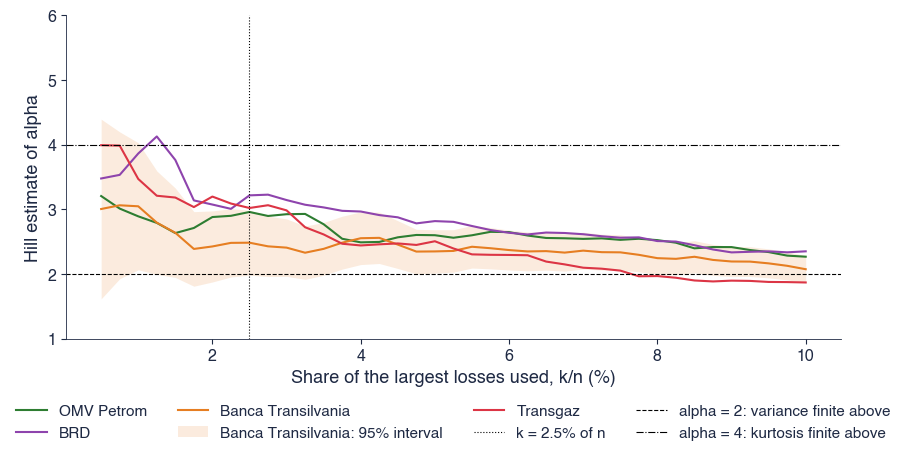

In [15]:
fig_hill_plot(STOCKS, 'sfm_ch5_hill_bvb', band='tlv', save=False)

In [16]:
x = losses('sp500').values
k = int(HILL_FRAC * len(x))
print('Hill VaR 0.1% of the S&P 500:', round(hill_quantile(x, k, 0.001), 2), '| empirical:', round(hist_var(x, 0.001), 2))

Hill VaR 0.1% of the S&P 500: 6.92 | empirical: 6.94


## 4. The mean excess function

- $e(u) = E[L - u \mid L > u]$: constant for the Exponential law, a rising line for Pareto-type tails.

In [17]:
def fig_mean_excess(names=ASSETS, save=True):
    """Empirical mean excess function of daily losses (as in SFEMeanExcessFun), with the threshold u (90% quantile)
    and the straight line implied by the GPD fitted above u: e(v) = (beta + xi (v - u)) / (1 - xi)."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.2))
    out = {}
    for ax, k in zip(axes.flat, names):
        x = losses(k).values
        us = np.quantile(x, np.linspace(0.5, 0.995, 120))
        e = mean_excess(x, us)
        f = pot(x)
        ax.plot(us, e, 'o', ms=3, color=COLORS[k], label='Empirical mean excess e(u)')
        v = np.linspace(f['u'], us[-1], 50)
        ax.plot(v, (f['beta'] + f['xi'] * (v - f['u'])) / (1 - f['xi']), color='black', lw=1.3, label='GPD fitted above u')
        ax.axvline(f['u'], color='black', lw=0.8, ls=':', label='u = 90% quantile of the losses')
        ax.set_title(LABELS[k], loc='left', fontsize=12)
        ax.set_xlabel('Threshold u (daily loss, %)')
        ax.set_ylabel('e(u) (%)')
        out[k] = {'u': f['u'], 'e_u': float(mean_excess(x, [f['u']])[0])}
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_mean_excess')
    return out

{'sp500': {'u': 1.163125046257596, 'e_u': 0.9150751232918093},
 'dax': {'u': 1.4975674911048038, 'e_u': 1.05037668540234},
 'bet': {'u': 1.375488295422436, 'e_u': 1.3036187400043298},
 'btc': {'u': 3.333460394611745, 'e_u': 3.024409489174604}}

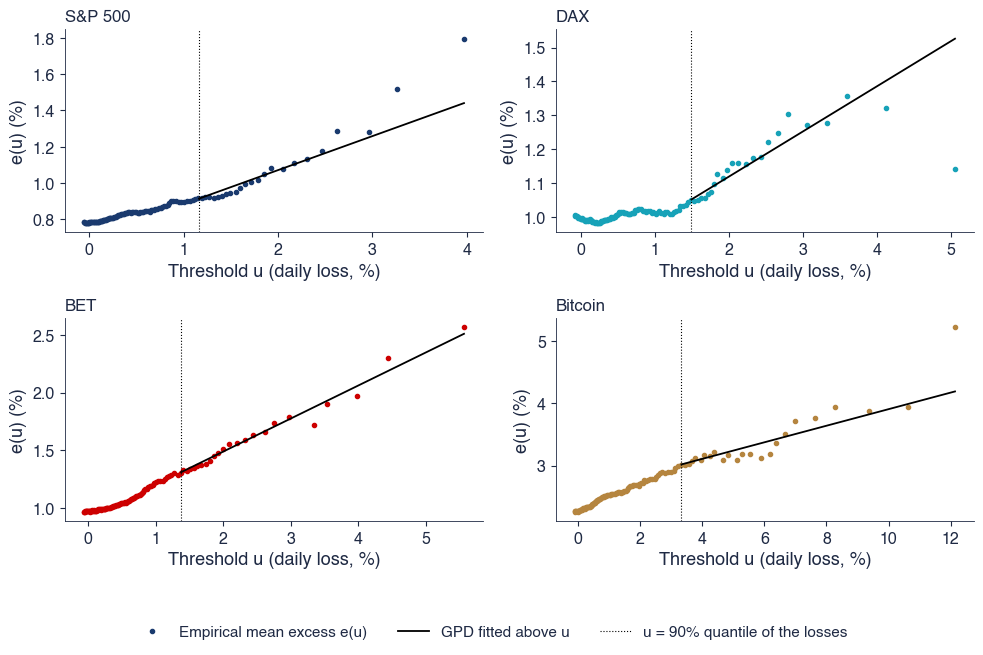

In [18]:
fig_mean_excess(save=False)

## 5. Block maxima and the GEV distribution

- The three extreme value laws; the Fisher–Tippett–Gnedenko theorem in a simulation.
- GEV fits to monthly maxima of daily losses; PP and QQ plots; return levels with bootstrap intervals.

In [19]:
def fig_gev_types(save=True):
    """Densities and distribution functions of the three extreme value laws (as in SFEevt1): Gumbel (xi = 0),
    Frechet (xi = 0.5) and Weibull (xi = -0.5), standard location and scale."""
    x = np.linspace(-4, 7, 600)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for xi, lab, c in [(0.0, 'Gumbel (xi = 0)', '#1A3A6E'), (0.5, 'Frechet (xi = 0.5)', '#CD0000'),
                       (-0.5, 'Weibull (xi = -0.5)', '#2E7D32')]:
        axes[0].plot(x, gev_pdf(x, xi, 0, 1), color=c, lw=1.6, label=lab)
        axes[1].plot(x, gev_cdf(x, xi, 0, 1), color=c, lw=1.6, label='_')
    axes[0].set_title('Density h(x)', loc='left', fontsize=12)
    axes[1].set_title('Distribution function H(x)', loc='left', fontsize=12)
    for ax in axes:
        ax.set_xlabel('x')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_gev_types')


def fig_maxima_sim(n=250, reps=5000, save=True):
    """Fisher-Tippett-Gnedenko in a simulation: maxima of n = 250 draws, normalised, against the limit law.
    Exponential(1): M - ln n -> Gumbel; Pareto(3): M / n^(1/3) -> Frechet; Uniform(0, 1): n (M - 1) -> Weibull."""
    rng = np.random.default_rng(SEED)
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
    cases = [('Exponential(1): M - ln n', lambda: rng.exponential(1, (reps, n)).max(1) - np.log(n), 0.0, '#1A3A6E', (-3, 7)),
             ('Pareto(3): M / n^(1/3)', lambda: (rng.pareto(3, (reps, n)) + 1).max(1) / n ** (1 / 3), 1 / 3, '#CD0000', (0, 4)),
             ('Uniform(0, 1): n (M - 1)', lambda: n * (rng.uniform(0, 1, (reps, n)).max(1) - 1), -1.0, '#2E7D32', (-5, 0.2))]
    out = {}
    for ax, (lab, draw, xi, c, lim) in zip(axes, cases):
        m = draw()
        x = np.linspace(*lim, 400)
        bins = np.linspace(*lim, 50)
        ax.hist(m, bins=bins, density=True, color=c, alpha=0.35, label='_')
        if xi == 0:
            f = gev_pdf(x, 0, 0, 1)
        elif xi > 0:
            f = gev_pdf(x, xi, 1, xi)                     # Frechet: P(M/n^(1/3) <= x) -> exp(-x^-3) = GEV(1/3, 1, 1/3)
        else:
            f = gev_pdf(x, -1, -1, 1)                    # Weibull: P(n(M-1) <= x) -> exp(x) for x <= 0 = GEV(-1, -1, 1)
        ax.plot(x, f, color='black', lw=1.4, label='Limit law (GEV)')
        ax.set_title(lab, loc='left', fontsize=11)
        out[lab] = float(np.mean(m))
    axes[0].bar([0], [0], color='#1A3A6E', alpha=0.35, label='Simulated maxima (5,000 samples)')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_maxima_sim')
    return out


def monthly_maxima(k):
    """Largest daily loss in each calendar month (blocks of about 21 trading days; 30 days for Bitcoin)."""
    L = losses(k)
    g = L.groupby([L.index.year, L.index.month])
    m = g.max()[g.count() >= 15]
    return m


def gev_table(names=ASSETS, B=200, seed=SEED):
    """GEV fit to the monthly maxima of daily losses; 10-year and 50-year return levels with bootstrap intervals."""
    rng = np.random.default_rng(seed)
    out = {}
    for k in names:
        m = monthly_maxima(k).values
        g = fit_gev(m)
        rl10, rl50 = return_level(g, 120), return_level(g, 600)
        bs = []
        for _ in range(B):
            s = rng.choice(m, len(m))
            try:
                c, mu, sig = stats.genextreme.fit(s, -g['xi'], loc=g['mu'], scale=g['sigma'])
                bs.append([-c, stats.genextreme.ppf(1 - 1 / 120, c, mu, sig)])
            except Exception:
                pass
        bs = np.array(bs)
        out[k] = dict(g, rl10=rl10, rl50=rl50, rl1=return_level(g, 12), rl10_lo=float(np.percentile(bs[:, 1], 2.5)),
                      rl10_hi=float(np.percentile(bs[:, 1], 97.5)), xi_lo=g['xi'] - 1.96 * g['se_xi'],
                      xi_hi=g['xi'] + 1.96 * g['se_xi'], max=float(m.max()), months=len(m),
                      years=len(m) / 12, n_above_rl10=int((m > rl10).sum()))
    return out


def fig_gev_ppqq(k='sp500', save=True):
    """PP and QQ plots of the GEV fitted to the monthly maxima of daily losses (as in SFEtailGEV_pp and _qq)."""
    m = np.sort(monthly_maxima(k).values)
    g = fit_gev(m)
    p = (np.arange(1, len(m) + 1) - 0.5) / len(m)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
    axes[0].plot(p, gev_cdf(m, g['xi'], g['mu'], g['sigma']), 'o', ms=3, color=COLORS[k], label='Monthly maxima')
    axes[0].plot([0, 1], [0, 1], color='black', lw=0.8, ls='--', label='45-degree line')
    axes[0].set_xlabel('Empirical probability')
    axes[0].set_ylabel('GEV probability')
    axes[0].set_title('PP plot', loc='left', fontsize=12)
    q = gev_ppf(p, g['xi'], g['mu'], g['sigma'])
    axes[1].plot(q, m, 'o', ms=3, color=COLORS[k], label='_')
    lim = [min(q.min(), m.min()), max(q.max(), m.max())]
    axes[1].plot(lim, lim, color='black', lw=0.8, ls='--', label='_')
    axes[1].set_xlabel('GEV quantile (%)')
    axes[1].set_ylabel('Monthly maximum of daily losses (%)')
    axes[1].set_title('QQ plot', loc='left', fontsize=12)
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig(f'sfm_ch5_gev_ppqq_{k}' if k != 'sp500' else 'sfm_ch5_gev_ppqq')
    return g


def fig_return_levels(gt, names=ASSETS, save=True):
    """Return level plot: the monthly maximum of daily losses exceeded on average once in T years (GEV fit)
    against the empirical return levels of the observed monthly maxima."""
    fig, ax = plt.subplots(figsize=(10, 4.2))
    T = np.logspace(np.log10(1 / 12 * 1.05), np.log10(100), 200)
    for k in names:
        g = gt[k]
        z = gev_ppf(1 - 1 / (12 * T), g['xi'], g['mu'], g['sigma'])
        ax.semilogx(T, z, color=COLORS[k], lw=1.6, label=f'{LABELS[k]} (GEV)')
        m = np.sort(monthly_maxima(k).values)
        pe = (np.arange(1, len(m) + 1)) / (len(m) + 1)
        ax.semilogx(1 / (12 * (1 - pe)), m, 'o', ms=2.5, color=COLORS[k], alpha=0.6, label='_')
    ax.axvline(10, color='black', lw=0.8, ls=':', label='10-year return period')
    ax.set_xlabel('Return period T (years, log scale)')
    ax.set_ylabel('Return level: daily loss (%)')
    st.legend_outside_bottom(ax, ncol=5, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_return_levels')

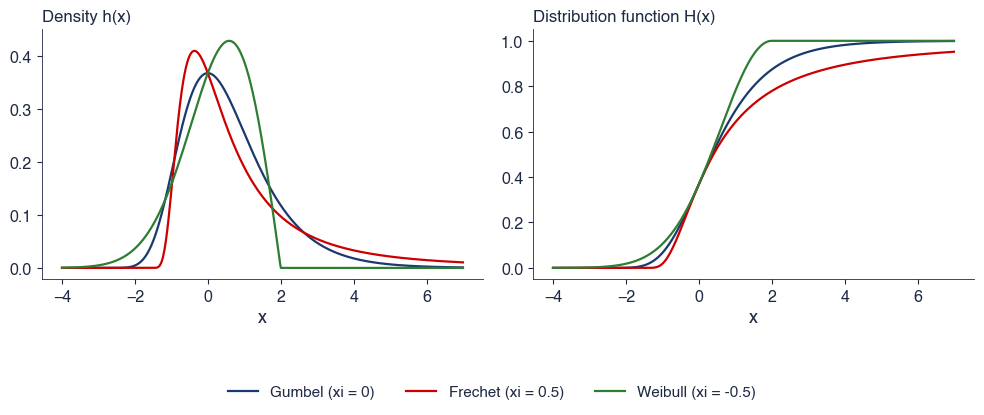

In [20]:
fig_gev_types(save=False)

{'Exponential(1): M - ln n': 0.5682071291329204,
 'Pareto(3): M / n^(1/3)': 1.3551955861476632,
 'Uniform(0, 1): n (M - 1)': -0.9750195680584449}

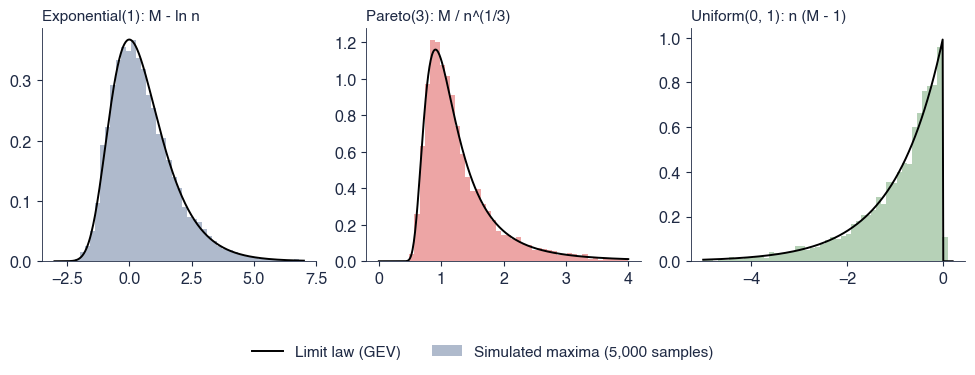

In [21]:
fig_maxima_sim(save=False)

In [22]:
gt = gev_table()
pd.DataFrame(gt).T[['months', 'xi', 'se_xi', 'mu', 'sigma', 'rl1', 'rl10', 'rl10_lo', 'rl10_hi', 'rl50', 'max']].round(2)

,months,xi,se_xi,mu,sigma,rl1,rl10,rl10_lo,rl10_hi,rl50,max
sp500,440.0,0.21,0.04,1.31,0.74,3.66,7.40,6.17,8.91,11.29,12.77
dax,440.0,0.17,0.04,1.69,0.91,4.45,8.41,7.07,9.93,12.21,13.05
bet,342.0,0.36,0.05,1.47,0.92,5.08,13.32,10.26,17.47,24.80,13.12
btc,144.0,0.23,0.08,5.19,2.85,14.57,30.28,21.21,41.06,47.36,46.47


{'xi': np.float64(0.2112668109350779),
 'mu': np.float64(1.3111290315419275),
 'sigma': np.float64(0.7365675423377133),
 'se_xi': np.float64(0.04017002795962758),
 'se_mu': np.float64(0.04005002908002001),
 'se_sigma': np.float64(0.032033843843044335),
 'nll': np.float64(612.5306997244592),
 'n': 440}

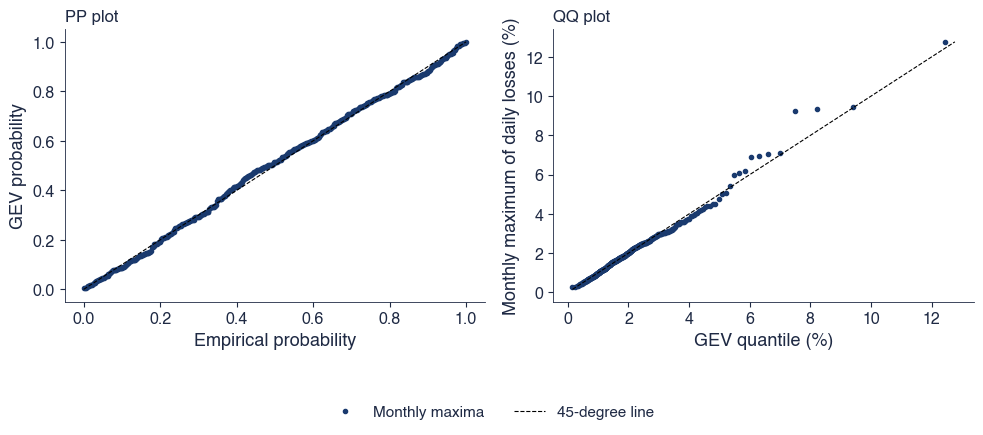

In [23]:
fig_gev_ppqq('sp500', save=False)

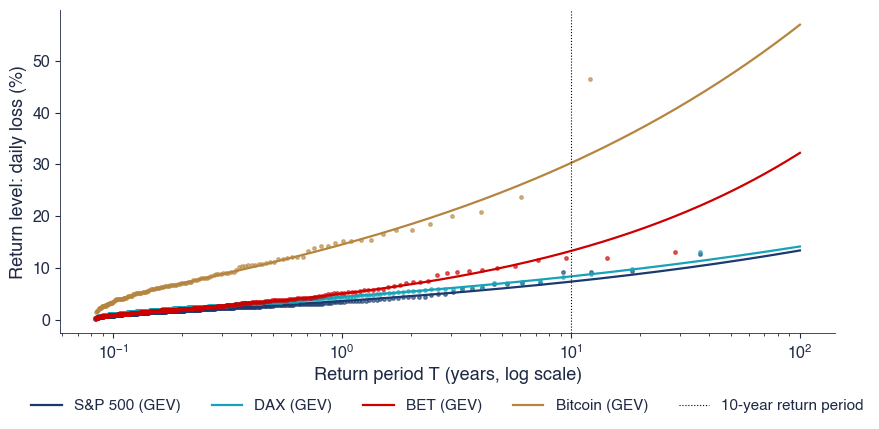

In [24]:
fig_return_levels(gt, save=False)

## 6. Peaks over threshold and the GPD

- GPD densities; threshold choice by parameter stability; GPD fits above the 90% quantile; PP and QQ plots; the fitted tails; waiting times of the crash days under the EVT tail.

In [25]:
def fig_gpd_densities(save=True):
    """GPD densities for xi = -0.3, 0, 0.3, 0.6 (beta = 1): the sign of xi decides the type of tail."""
    y = np.linspace(0, 6, 400)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for xi, c in [(-0.3, '#2E7D32'), (0.0, '#1A3A6E'), (0.3, '#E67E22'), (0.6, '#CD0000')]:
        axes[0].plot(y, stats.genpareto.pdf(y, xi, 0, 1), color=c, lw=1.6, label=f'xi = {xi:g}')
        yy = np.logspace(-1, 2, 300)
        sf = stats.genpareto.sf(yy, xi, 0, 1)
        ok = sf > 1e-9
        axes[1].loglog(yy[ok], sf[ok], color=c, lw=1.6, label='_')
    axes[0].set_title('Density g(y)', loc='left', fontsize=12)
    axes[1].set_title('P(Y > y), log-log axes', loc='left', fontsize=12)
    axes[0].set_xlabel('Excess y')
    axes[1].set_xlabel('Excess y (log scale)')
    axes[1].set_ylim(1e-6, 1.2)
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_gpd_densities')


def threshold_stability(k, qs=np.round(np.arange(0.80, 0.991, 0.01), 2)):
    """xi_hat of the GPD with its 95% interval for thresholds u at the 80%, ..., 99% quantiles of the losses."""
    x = losses(k).values
    rows = []
    for q in qs:
        f = pot(x, q)
        rows.append({'q': float(q), 'u': f['u'], 'n_u': f['n_u'], 'xi': f['xi'], 'se': f['se_xi'],
                     'var1': pot_var(f, 0.01), 'var01': pot_var(f, 0.001)})
    return rows


def fig_threshold_stability(names=('sp500', 'bet'), save=True):
    """Parameter stability plot: xi_hat (95% interval) and VaR 1% against the threshold quantile."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    out = {}
    for k in names:
        rows = threshold_stability(k)
        q = np.array([r['q'] for r in rows]) * 100
        xi = np.array([r['xi'] for r in rows])
        se = np.array([r['se'] for r in rows])
        axes[0].plot(q, xi, 'o-', ms=3, color=COLORS[k], label=LABELS[k])
        axes[0].fill_between(q, xi - 1.96 * se, xi + 1.96 * se, color=COLORS[k], alpha=0.15, lw=0)
        axes[1].plot(q, [r['var1'] for r in rows], 'o-', ms=3, color=COLORS[k], label='_')
        out[k] = rows
    for ax in axes:
        ax.axvline(100 * POT_Q, color='black', lw=0.8, ls=':')
        ax.set_xlabel('Threshold u: quantile of the losses (%)')
    axes[0].axhline(0, color='black', lw=0.8, ls='--')
    axes[0].set_ylabel('xi-hat (95% interval)')
    axes[1].set_ylabel('EVT VaR 1% (%)')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_threshold_stability')
    return out


def fig_gpd_ppqq(k='sp500', save=True, fname=None):
    """PP and QQ plots of the GPD fitted to the excesses over u (as in SFEtailGPareto_pp and _qq)."""
    x = losses(k).values
    f = pot(x)
    y = np.sort(x[x > f['u']] - f['u'])
    p = (np.arange(1, len(y) + 1) - 0.5) / len(y)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
    axes[0].plot(p, stats.genpareto.cdf(y, f['xi'], 0, f['beta']), 'o', ms=2.5, color=COLORS[k], label='Excesses over u')
    axes[0].plot([0, 1], [0, 1], color='black', lw=0.8, ls='--', label='45-degree line')
    axes[0].set_xlabel('Empirical probability')
    axes[0].set_ylabel('GPD probability')
    axes[0].set_title('PP plot', loc='left', fontsize=12)
    q = stats.genpareto.ppf(p, f['xi'], 0, f['beta'])
    axes[1].plot(q, y, 'o', ms=2.5, color=COLORS[k], label='_')
    lim = [0, max(q.max(), y.max())]
    axes[1].plot(lim, lim, color='black', lw=0.8, ls='--', label='_')
    axes[1].set_xlabel('GPD quantile of the excess (%)')
    axes[1].set_ylabel('Observed excess L - u (%)')
    axes[1].set_title('QQ plot', loc='left', fontsize=12)
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig(fname or 'sfm_ch5_gpd_ppqq')
    return {'q_top': float(q[-1]), 'y_top': float(y[-1])}


def risk_table(names=ASSETS):
    """VaR 1%, ES 2.5% and VaR 0.1% of daily losses: EVT (POT), historical simulation, Normal; Hill quantile."""
    out = {}
    for k in names:
        x = losses(k).values
        f = pot(x)
        kk = int(HILL_FRAC * len(x))
        out[k] = {'pot': f, 'n': len(x)}
        for lab, p in [('var1', 0.01), ('var01', 0.001)]:
            out[k][lab] = {'EVT': pot_var(f, p), 'Historical': hist_var(x, p), 'Normal': normal_var(x, p),
                           'Hill': hill_quantile(x, kk, p)}
        out[k]['es25'] = {'EVT': pot_es(f, 0.025), 'Historical': hist_es(x, 0.025), 'Normal': normal_es(x, 0.025)}
        out[k]['max'] = float(x.max())
    return out


def fig_tail_fit(rt, names=ASSETS, save=True):
    """The fitted tail: empirical P(L > x) above u (log-log) against the POT tail and the Normal tail, with the
    EVT VaR 1% and VaR 0.1%."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.4))
    for ax, k in zip(axes.flat, names):
        x = losses(k).values
        n = len(x)
        f = rt[k]['pot']
        s = np.sort(x)[::-1]
        emp = np.arange(1, n + 1) / n
        keep = s > f['u']
        ax.loglog(s[keep], emp[keep], 'o', ms=3.2, color=MODEL_COL['Data'], zorder=3, label='Data: share of days with a loss above x')
        xx = np.logspace(np.log10(f['u']), np.log10(2 * s[0]), 200)
        ax.loglog(xx, pot_tail_prob(f, xx), color=MODEL_COL['EVT'], lw=1.1, zorder=2, label='EVT: GPD above u')
        pn = stats.norm.sf(xx, np.mean(x), np.std(x, ddof=1))
        ok = pn > 1e-7
        ax.loglog(xx[ok], pn[ok], color=MODEL_COL['Normal'], ls='--', label='Normal distribution')
        for p, ls in [(0.01, ':'), (0.001, '-.')]:
            ax.axhline(p, color='black', lw=0.6, ls=ls, label='p = 1%' if p == 0.01 else 'p = 0.1%')
        ax.set_ylim(1e-5, 0.15)
        ax.set_title(f"{LABELS[k]}: xi = {f['xi']:.2f}", loc='left', fontsize=12)
        ax.set_xlabel('Loss x (%, log scale)')
        ax.set_ylabel('P(L > x)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_tail_fit')


def crash_waiting(rt, ct, c87):
    """Waiting time (years) of the largest observed loss, and of the 1987 crash, under the Normal and the EVT tail."""
    out = {}
    for k in ct:
        f = rt[k]['pot']
        days = 365 if k == 'btc' else 252
        p = float(pot_tail_prob(f, -ct[k]['ret']))
        out[k] = {'p_evt': p, 'years_evt': 1 / (p * days)}
    f = rt['sp500']['pot']
    p = float(pot_tail_prob(f, -c87['logret']))
    out['1987'] = {'p_evt': p, 'years_evt': 1 / (p * 252)}
    return out

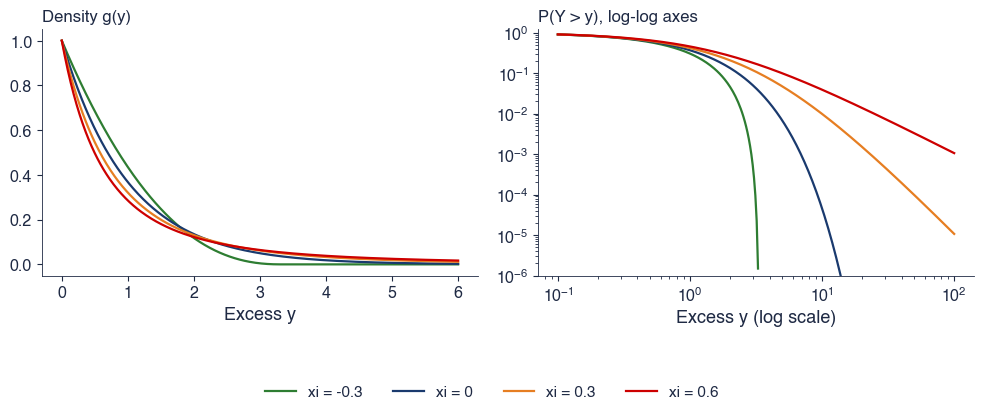

In [26]:
fig_gpd_densities(save=False)

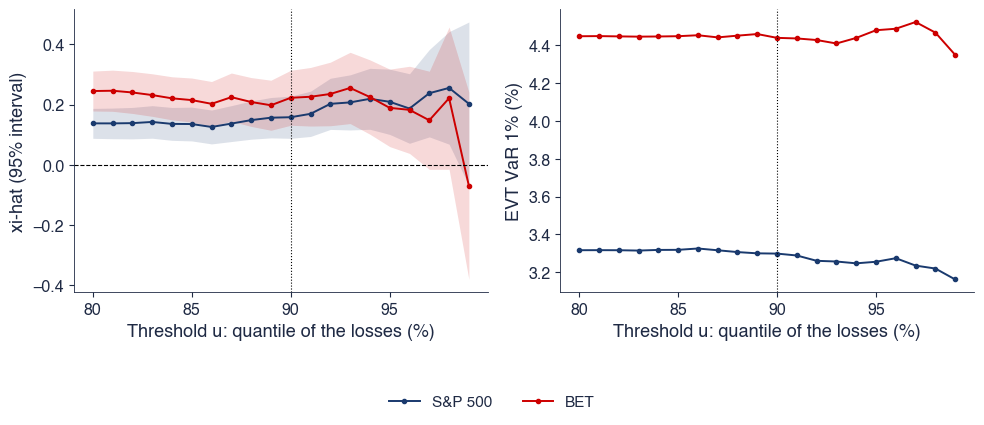

In [27]:
stab = fig_threshold_stability(save=False)

{'q_top': 11.110056291350821, 'y_top': 11.602093260276325}

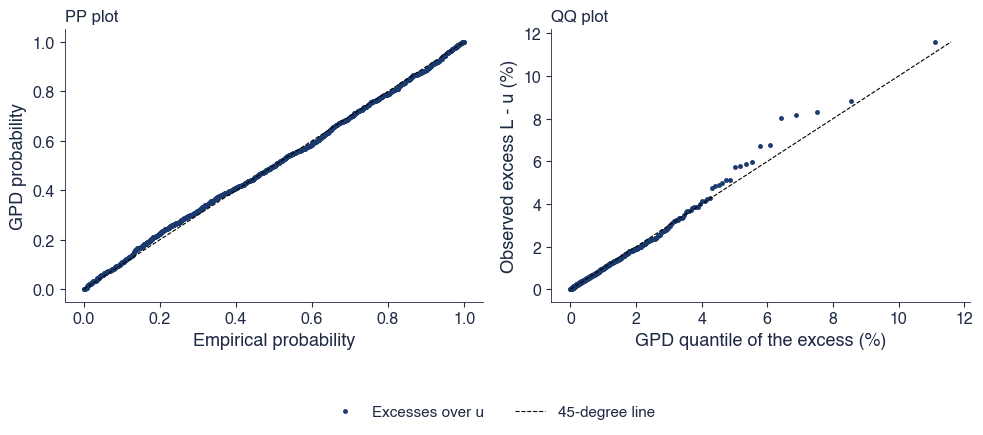

In [28]:
fig_gpd_ppqq('sp500', save=False)

In [29]:
rt = risk_table(ASSETS + STOCKS)
pd.DataFrame({k: v['pot'] for k, v in rt.items()}).T[['u', 'n_u', 'xi', 'se_xi', 'beta']].round(3)

,u,n_u,xi,se_xi,beta
sp500,1.163,924.0,0.158,0.036,0.769
dax,1.498,929.0,0.118,0.038,0.927
bet,1.375,725.0,0.223,0.047,1.018
btc,3.333,439.0,0.118,0.050,2.663
snp,1.666,382.0,0.222,0.059,0.901
brd,1.777,377.0,0.163,0.058,0.963
tlv,1.707,379.0,0.259,0.062,1.012
tgn,1.432,373.0,0.121,0.062,1.111


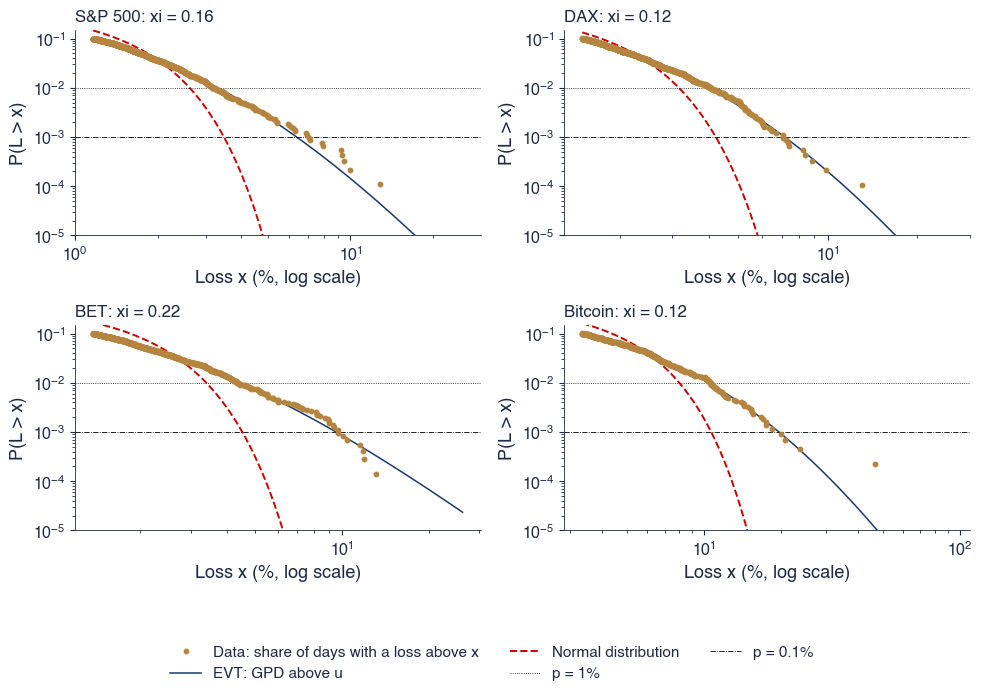

In [30]:
fig_tail_fit(rt, save=False)

In [31]:
pd.DataFrame(crash_waiting(rt, crash_table(), crash_1987())).T.round(4)

,p_evt,years_evt
sp500,0.0000,88.8435
dax,0.0000,85.0812
bet,0.0003,11.9857
btc,0.0000,237.0565
1987,0.0000,1602.4803


## 7. VaR and ES by EVT

- VaR 1%, ES 2.5% and VaR 0.1%: EVT (POT), historical simulation, the Normal distribution and the Hill quantile.
- Out of sample: VaR estimated until 2019, exceedances counted in 2020–2026.

In [32]:
def out_of_sample(names=ASSETS, split=SPLIT):
    """Estimate VaR 1% and VaR 0.1% on the losses until `split` (EVT, historical, Normal); count the days after
    `split` with a loss above each VaR (expected rates: 1% and 0.1%)."""
    out = {}
    for k in names:
        L = losses(k)
        a, b = L.loc[:split].values, L.loc[split:].iloc[1:].values
        f = pot(a)
        row = {'n_est': len(a), 'n_test': len(b), 'first_test': L.loc[split:].index[1].date().isoformat()}
        for lab, p in [('var1', 0.01), ('var01', 0.001)]:
            v = {'EVT': pot_var(f, p), 'Historical': hist_var(a, p), 'Normal': normal_var(a, p)}
            row[lab] = {m: {'var': x, 'exc': int((b > x).sum())} for m, x in v.items()}
            row[lab]['expected'] = p * len(b)
        out[k] = row
    return out


def fig_oos(k='sp500', split=SPLIT, save=True):
    """Daily losses after the estimation period with the VaR 1% of the three methods (estimated until 2019)."""
    L = losses(k)
    a, b = L.loc[:split].values, L.loc[split:].iloc[1:]
    f = pot(a)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(b.index, b.values, color=COLORS[k], lw=0.6, label=f'{LABELS[k]} daily loss (%)')
    for m, v, ls in [('Normal', normal_var(a, 0.01), '--'), ('Historical', hist_var(a, 0.01), ':'), ('EVT', pot_var(f, 0.01), '-')]:
        ax.axhline(v, color=MODEL_COL[m], lw=1.3, ls=ls, label=f'VaR 1%, {m}: {v:.2f}%')
    v01 = pot_var(f, 0.001)
    ax.axhline(v01, color=MODEL_COL['EVT'], lw=1.0, ls='-.', label=f'VaR 0.1%, EVT: {v01:.2f}%')
    ax.set_ylabel('Daily loss (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch5_oos')

In [33]:
pd.DataFrame({k: {f'{l} {m}': v[l][m] for l in ['var1', 'es25', 'var01'] for m in v[l]} for k, v in rt.items()}).T.round(2)

,var1 EVT,var1 Historical,var1 Normal,var1 Hill,es25 EVT,es25 Historical,es25 Normal,var01 EVT,var01 Historical,var01 Normal,var01 Hill
sp500,3.30,3.15,2.60,3.19,3.49,3.48,2.62,6.37,6.94,3.47,6.92
dax,3.95,4.02,3.16,3.88,4.13,4.15,3.18,7.17,6.97,4.21,8.37
bet,4.44,4.33,3.39,4.37,4.81,4.80,3.41,9.56,9.64,4.52,10.69
btc,10.38,10.51,7.99,9.95,10.90,10.84,8.03,19.61,18.05,10.65,23.30
snp,4.38,4.29,3.70,4.27,4.71,4.70,3.72,8.89,8.32,4.94,9.29
brd,4.47,4.50,3.81,4.36,4.72,4.70,3.83,8.39,7.85,5.07,8.93
tlv,4.89,5.10,4.01,4.79,5.35,5.37,4.03,10.68,10.50,5.35,12.10
tgn,4.39,4.40,3.50,4.28,4.61,4.59,3.52,8.29,8.23,4.68,9.18


In [34]:
oos = out_of_sample()
pd.DataFrame({k: {f'{l} {m}': o[l][m]['exc'] for l in ['var1', 'var01'] for m in ['EVT', 'Historical', 'Normal']} | {'expected 1%': o['var1']['expected'], 'expected 0.1%': o['var01']['expected']} for k, o in oos.items()}).T.round(1)

,var1 EVT,var1 Historical,var1 Normal,var01 EVT,var01 Historical,var01 Normal,expected 1%,expected 0.1%
sp500,25.0,26.0,44.0,5.0,3.0,23.0,16.9,1.7
dax,15.0,12.0,31.0,2.0,2.0,8.0,17.1,1.7
bet,4.0,5.0,13.0,0.0,1.0,4.0,16.7,1.7
btc,8.0,10.0,23.0,1.0,1.0,8.0,24.5,2.5


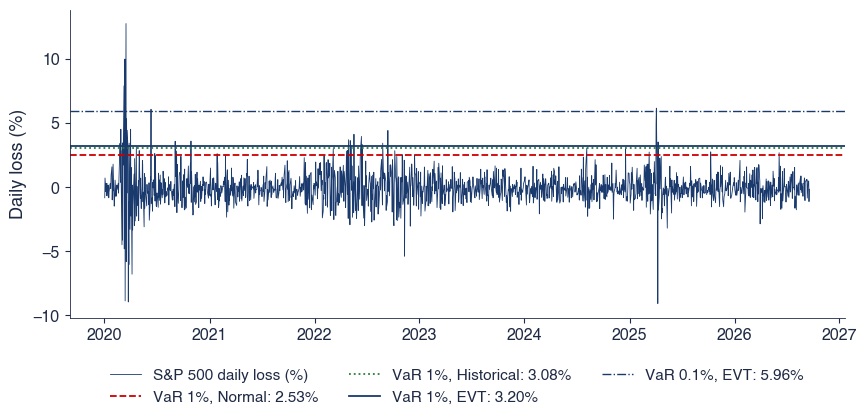

In [35]:
fig_oos(save=False)

## 8. AI for scientific discovery: has the tail of the BET changed?

- Open question: is the tail of BET losses lighter or heavier after 2010 than before, once volatility is removed?
- Starter result: the Hill index before and after 1 January 2010, with block-bootstrap standard errors.
- Check before trusting any answer, yours or an AI's: the sign of the losses, the rule for $k$ fixed in advance, overlapping windows, and whether the change survives returns divided by a rolling volatility.

In [36]:
def bet_periods(k='bet', edge='2010-01-01', B=500, seed=SEED):
    """Hill index of daily BET losses (k = 2.5% of n) before and after 1 January 2010, with moving-block bootstrap
    standard errors and the z statistic of the difference."""
    L = losses(k)
    res = {}
    for lab, x in [('before', L.loc[:edge].iloc[:-1]), ('after', L.loc[edge:])]:
        h = hill_inference(x.values, B=B, seed=seed)
        res[lab] = dict(h, first=x.index[0].date().isoformat(), last=x.index[-1].date().isoformat())
    res['z'] = (res['after']['alpha'] - res['before']['alpha']) / np.sqrt(res['before']['se_block'] ** 2 + res['after']['se_block'] ** 2)
    return res

In [37]:
bp = bet_periods()
print('z =', round(bp['z'], 2))
pd.DataFrame({p: bp[p] for p in ['before', 'after']}).T[['first', 'last', 'n', 'k', 'u', 'alpha', 'se_block']]

z = -1.73


,first,last,n,k,u,alpha,se_block
before,1997-09-22,2009-12-23,3055,76,3.950111,2.8975,0.325289
after,2010-01-04,2026-09-18,4187,104,2.007761,2.162345,0.273158
